# Extract ROI Click Point

Recover the annotator click point from a saved NEUSEG ROI.
Start by loading one slide's NEUSEG results (masks + `annotations.geojson`).

In [11]:
import os
import sys
import glob

import numpy as np

# Helper_Functions lives in evaluation/, one level up from this notebook
sys.path.insert(0, os.path.abspath(os.path.join("..", "evaluation")))
from Helper_Functions.loading import get_neuseg_results

In [2]:
# Slide of interest + where its data lives
curr_slidename = '2017-187-26F_L_OFC_AT8_1K_03-11-19_RL'

data_dir         = '/Volumes/Extreme SSD/Research/Projects/Individual Covariance Networks/Histopathology/NEUSEG_Experiment'
WSI_dir          = os.path.join(data_dir, 'bvFTD_Eval_cohort')
neuseg_annot_dir = os.path.join(data_dir, 'GM_WM_Seg_Results_bvFTD_WSIs_20260216_Eval_Cohort')

# the .svs sits under a subtype folder; the NEUSEG result dir is nested by subtype/subject
svs_path = glob.glob(os.path.join(WSI_dir, "*", f"{curr_slidename}.svs"))[0]
neuseg_dir = next(d for d, _, fns in os.walk(neuseg_annot_dir)
                  if os.path.basename(d) == curr_slidename and "annotations.geojson" in fns)

print("svs   :", svs_path)
print("neuseg:", neuseg_dir)


svs   : /Volumes/Extreme SSD/Research/Projects/Individual Covariance Networks/Histopathology/NEUSEG_Experiment/bvFTD_Eval_cohort/FTLD-TAU/2017-187-26F_L_OFC_AT8_1K_03-11-19_RL.svs
neuseg: /Volumes/Extreme SSD/Research/Projects/Individual Covariance Networks/Histopathology/NEUSEG_Experiment/GM_WM_Seg_Results_bvFTD_WSIs_20260216_Eval_Cohort/FTLD-TAU/2017-187/2017-187-26F_L_OFC_AT8_1K_03-11-19_RL/2017-187-26F_L_OFC_AT8_1K_03-11-19_RL


full-res=37848x27583  thumb=2365x1723  scale=16.0034  mpp=0.5045
mask contours -> GM-WM: 2 polys (2 bodies + 0 holes) | GM-CSF: 2 polys (2 bodies + 0 holes)
geojson ROI 'neuseg_0': GM-WM (20, 2) | GM-CSF (20, 2)


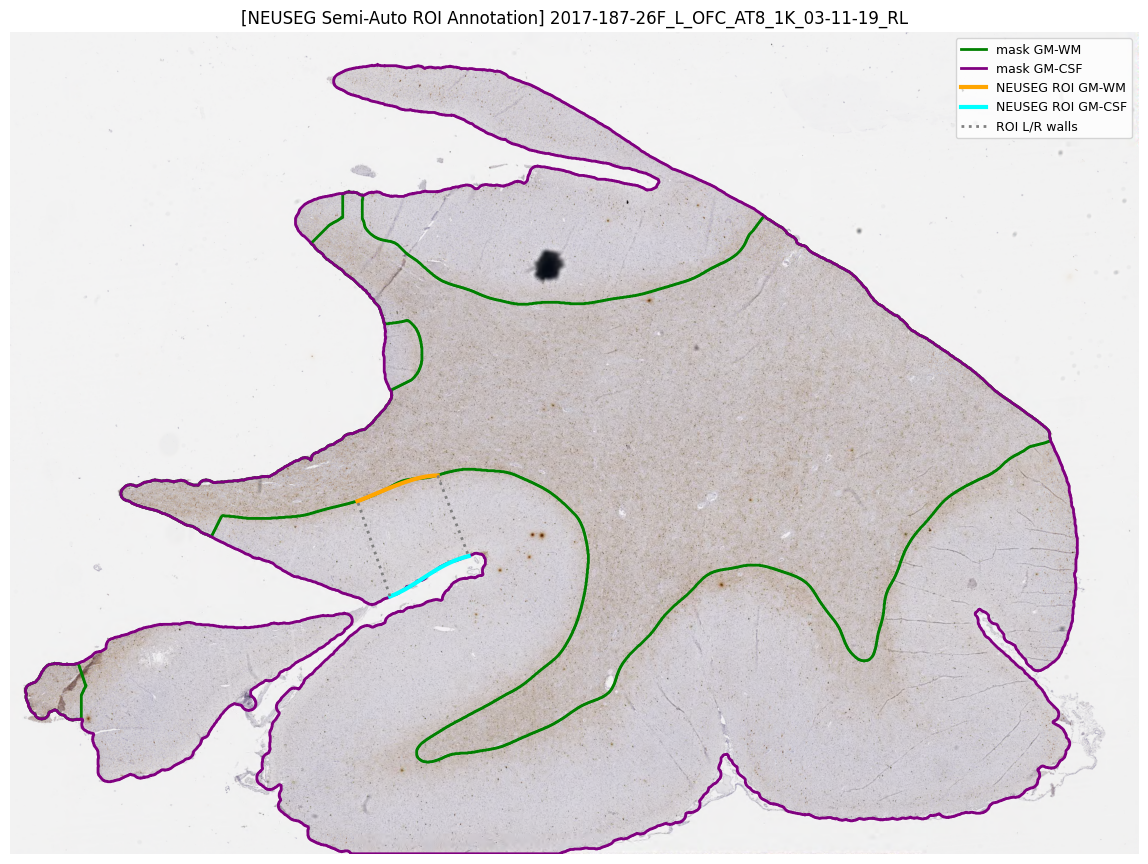

ROIs: ['neuseg_0']


In [ ]:
# Load the NEUSEG output in FULL-RES coords:
neuseg_res = get_neuseg_results(curr_slidename, neuseg_dir, svs_path, verbose=True)

print(f'ROIs: {list(neuseg_res["annot"])}')


## Reverse-engineer the click point

`pdnl_annotator.py` builds a GM ROI from **one** click `ctr` (`Canvas.get_roi`):

1. ray-cast from `ctr` in 360 orientations -> shortest CSF-WM chord (the cortical *spine*),
2. step `+/- l` **perpendicular** to that spine -> two lateral points `p0`, `p1`,
3. ray-cast again at `p0` / `p1` -> the two saved walls (`L` / `R`).

Step 2 makes `p0` and `p1` symmetric about the click, so

$$ctr = \tfrac{1}{2}(p_0 + p_1)$$

holds **exactly**, and `p0`/`p1` lie *on* the saved walls. The one thing the geojson does
not record is how deep along each wall they sat -- that is the `depth` argument below.

In [12]:
def estimate_click_point(roi, depth=0.5):
    """Estimate the annotator click point that produced a NEUSEG GM ROI.

    ctr == midpoint(p0, p1) exactly, and p0/p1 lie on the two saved walls, so the
    click is recovered from the walls alone. `depth` is where p0/p1 sat along their
    wall (0 = CSF end, 1 = WM end); only its 0.5 default is unbiased.

    roi   : {'gm_csf','gm_wm','left','right'} from parse_rois / get_neuseg_results
    Returns (2,) point in the SAME coordinate space as `roi` (full-res here).
    """
    csf, wm = roi["gm_csf"], roi["gm_wm"]
    dist = lambda p, curve: np.min(np.linalg.norm(curve - p, axis=1))

    pts = []
    for wall in (roi["left"], roi["right"]):
        a, b = wall                              # each wall is a 2-point straight segment
        if dist(a, csf) > dist(a, wm):           # order the ends as (CSF end, WM end)
            a, b = b, a
        pts.append(a + depth * (b - a))
    return (pts[0] + pts[1]) / 2


In [13]:
# Recover the click for every ROI on this slide.
# full-res -> divide by neuseg_res["scale"] to get the thumbnail/mask coords the annotator clicked in.
for roi_name, roi in neuseg_res["annot"].items():
    click = estimate_click_point(roi)
    print(f'{roi_name}: full-res={np.round(click, 1)}  thumbnail={np.round(click / neuseg_res["scale"], 1)}')


neuseg_0: full-res=[13526.9 16771.5]  thumbnail=[ 845.2 1048. ]


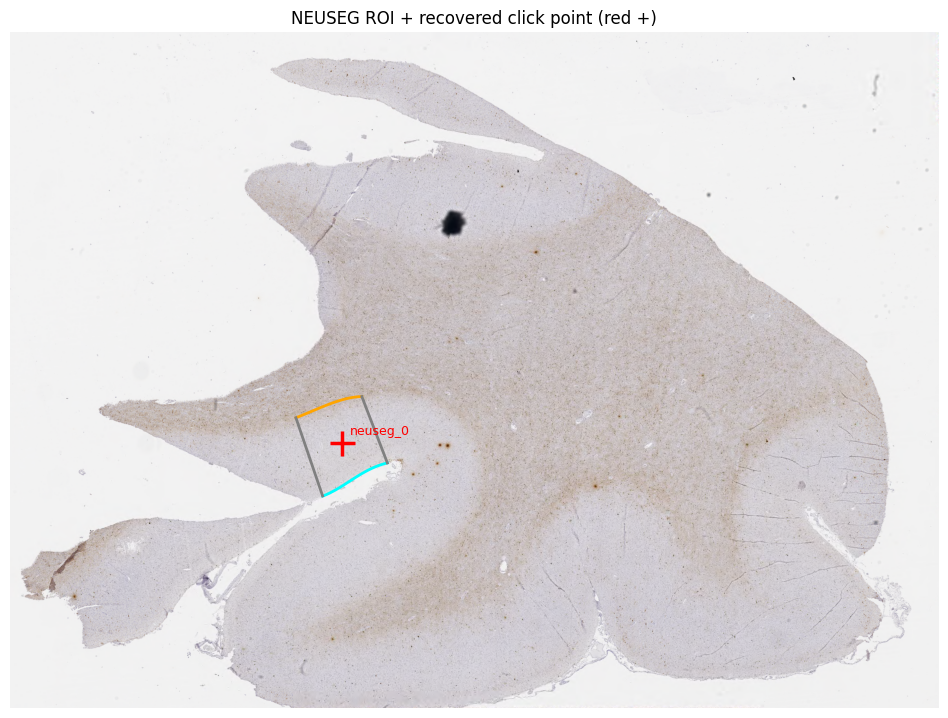

In [14]:
# Sanity check: draw the ROI + the recovered click on the thumbnail.
import matplotlib.pyplot as plt
import pdnl_sana.image

thumb = pdnl_sana.image.Frame(os.path.join(neuseg_dir, "thumbnail.png")).img
s = neuseg_res["scale"]

fig, ax = plt.subplots(figsize=(10, 10 * thumb.shape[0] / thumb.shape[1]))
ax.imshow(thumb)
for roi_name, roi in neuseg_res["annot"].items():
    for key, color in [("gm_csf", "cyan"), ("gm_wm", "orange"), ("left", "gray"), ("right", "gray")]:
        p = roi[key] / s
        ax.plot(p[:, 0], p[:, 1], color=color, lw=2)
    cx, cy = estimate_click_point(roi) / s
    ax.plot(cx, cy, "r+", markersize=18, markeredgewidth=2.5)
    ax.annotate(roi_name, (cx, cy), color="red", fontsize=9, xytext=(6, 6), textcoords="offset points")
ax.set_title("NEUSEG ROI + recovered click point (red +)")
ax.axis("off")
plt.tight_layout()
plt.show()
